In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import math
import pickle
import sbi.utils as utils
import torch
from seaborn import histplot, kdeplot, boxplot, violinplot
from time import time
import sys  
sys.path.insert(1, '../')
from collective_posterior import CollectivePosterior
from simulators import wrapper
from evo_sim import evo_sim, EVO_SIM_wrapper, plot_vec30
from inference_utils import get_prior
import warnings
warnings.simplefilter('ignore', FutureWarning)


def EVO_SIM_wrapper(reps, parameters, seed=None):
    evo_reps = torch.empty(reps, 30)
    for i in range(reps):
        out=evo_sim(parameters)
        evo_reps[i,:] = torch.tensor(out)
    return evo_reps

# for making larger graphs
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize

posterior = pickle.load(open('posterior_EVO_SIM_30000_20.pkl', 'rb'))
prior = get_prior('EVO_SIM')


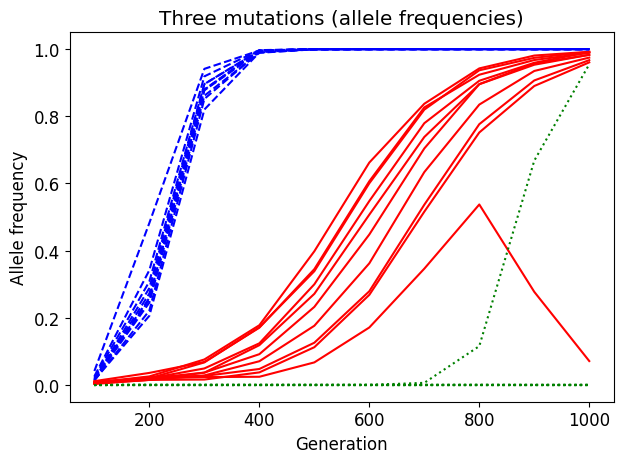

In [13]:
change_font(12)
th = prior.sample((1,))[0]
X = EVO_SIM_wrapper(10, th)

fig, ax = plt.subplots()
for x in X:
    plot_vec30(x, ax=ax)

MCMC from top SN: 100%|██████████| 500/500 [00:05<00:00, 71.73it/s]


Drawing 500 posterior samples:   0%|          | 0/500 [00:00<?, ?it/s]

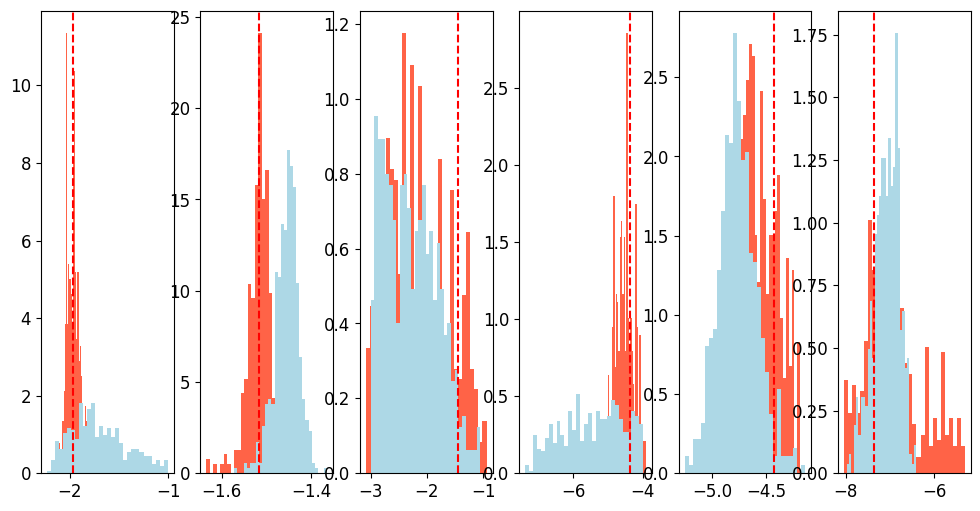

In [14]:
cp = CollectivePosterior(prior, amortized_posterior=posterior, log_C=1, Xs=X, epsilon=-10)
cp.get_log_C()

samples_cp = cp.mcmc_from_top_sn(500)

posterior_iid = pickle.load(open('posterior_iid.pkl', 'rb'))
samples_iid = posterior_iid.set_default_x(X).sample((500,))

# histograms in 6 axes
fig, ax = plt.subplots(1, 6, figsize=(12, 6))
for i in range(6):
    ax[i].hist(samples_cp[:,i].numpy(), bins=30, density=True, color='tomato')
    ax[i].hist(samples_iid[:,i].numpy(), bins=30, density=True, color='lightblue')
    ax[i].axvline(th.numpy()[i], color='r', linestyle='--')

Text(0, 0.5, '')

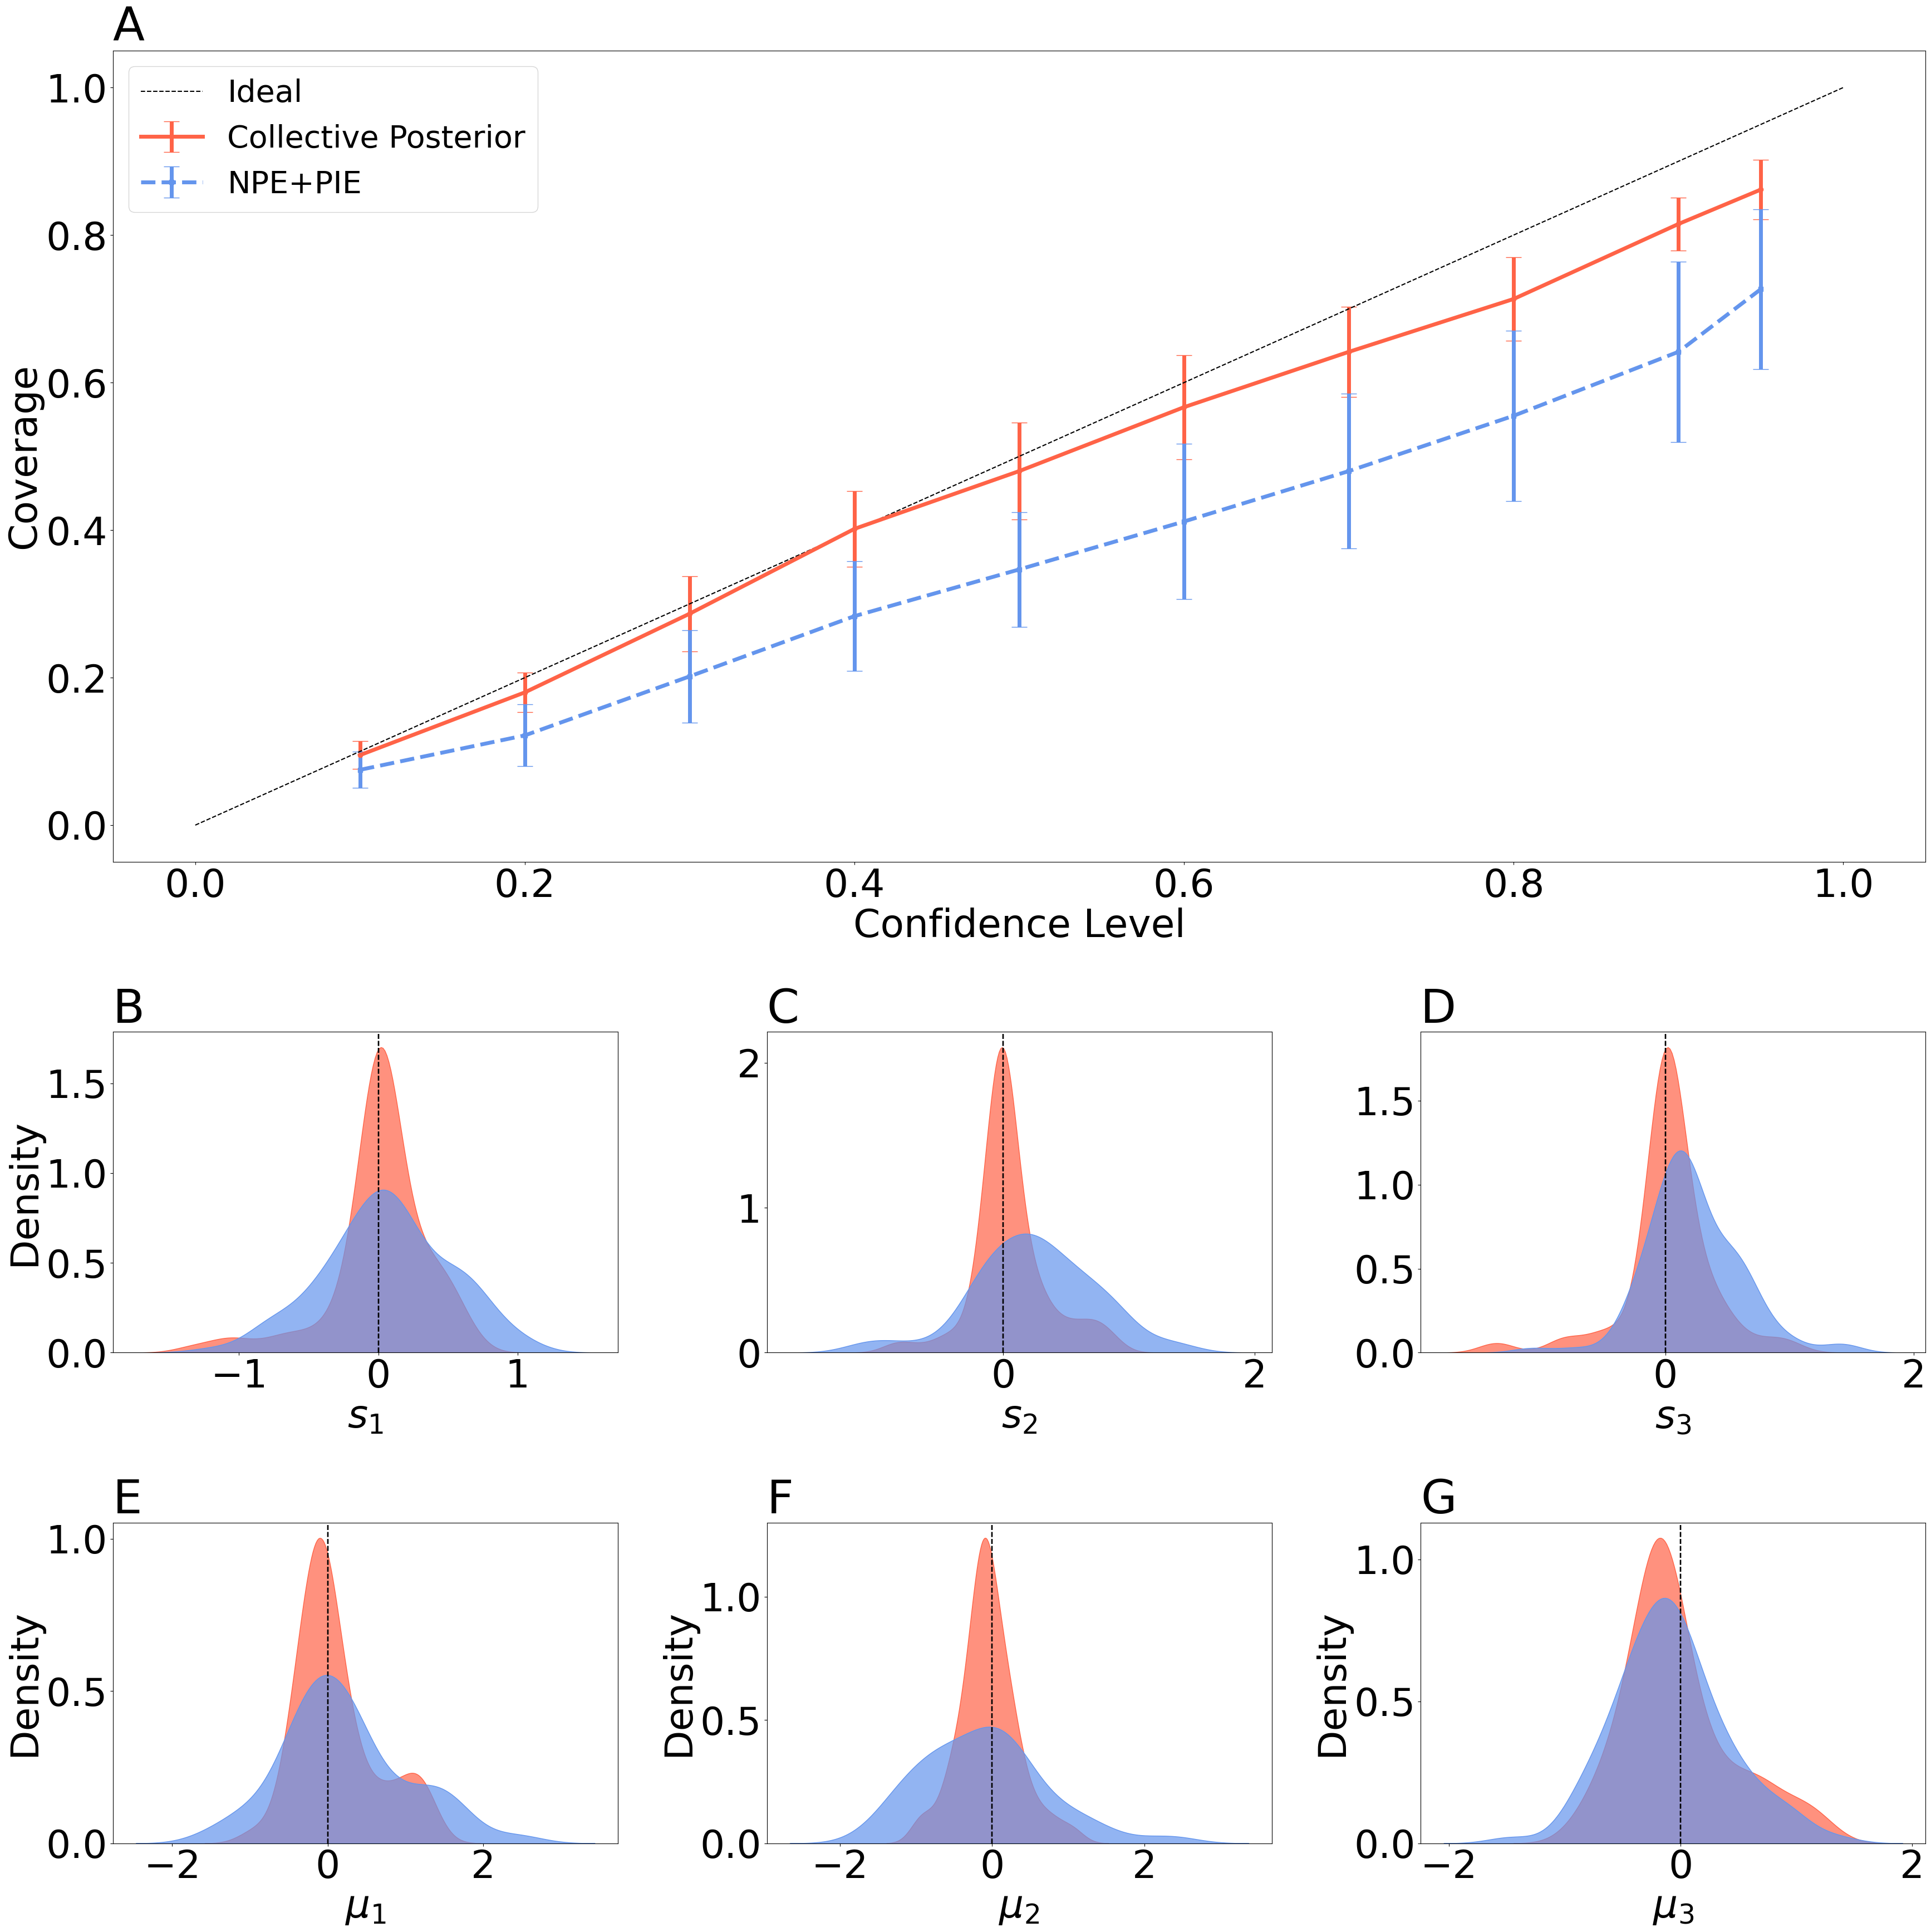

In [21]:
change_font(50)

# plot accuracy in 2X3 axis
def plot_accuracy(acc, ax, color, label, hatch):
    parameters = ['$s_1$', '$s_2$', '$s_3$', '$\\mu_1$', '$\\mu_2$', '$\\mu_3$']
    for i in range(len(ax)):

        kdeplot(acc[:,i],ax=ax[i], color=color, alpha=0.7, fill=True)
        ax[i].axvline(0, color='k', lw=1.7, ls='--')
        ax[i].set_xlabel(parameters[i])
    return

conf_levels = np.array([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95], dtype=float)
def plot_covs(ax, covs1, covs2):
    """
    Plot mean coverage across parameters (and repeats) with error bars showing
    variability among parameters.

    Expects covs arrays of shape (n_repeats, n_conf, n_params) or (n_conf, n_params).
    """
    import numpy as np

    def to_np(x):
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
        return np.asarray(x)

    a1 = to_np(covs1)
    a2 = to_np(covs2)

    # normalize shapes to (n_repeats, n_conf, n_params)
    if a1.ndim == 2:
        a1 = a1[None, ...]
    if a2.ndim == 2:
        a2 = a2[None, ...]

    n_reps, n_conf, n_params = a1.shape

    # For each confidence level, compute per-parameter mean across repeats,
    # then compute the mean across parameters (value to plot) and the std across parameters
    mean1 = np.empty(n_conf)
    sd1 = np.empty(n_conf)
    mean2 = np.empty(n_conf)
    sd2 = np.empty(n_conf)

    for j in range(n_conf):
        # shape (n_reps, n_params) -> mean over repeats -> (n_params,)
        per_param_mean1 = a1[:, j, :].mean(axis=0)
        per_param_mean2 = a2[:, j, :].mean(axis=0)
        # mean across parameters
        mean1[j] = per_param_mean1.mean()
        mean2[j] = per_param_mean2.mean()
        # variability among parameters (std). Use std (not se) as requested.
        sd1[j] = per_param_mean1.std(ddof=0)
        sd2[j] = per_param_mean2.std(ddof=0)

    palette = {'Collective Posterior': 'tomato', 'NPE+PIE': 'cornflowerblue'}

    ax.errorbar(conf_levels, mean1, yerr=sd1, label='Collective Posterior',
                color=palette['Collective Posterior'], marker='o', linestyle='-', capsize=10, linewidth=5)
    ax.errorbar(conf_levels, mean2, yerr=sd2, label='NPE+PIE',
                color=palette['NPE+PIE'], marker='s', linestyle='--', capsize=10, linewidth=5)
    ax.plot(np.linspace(0, 1, 100), np.linspace(0, 1, 100), color='k', linestyle='--', label='Ideal')
    ax.legend(fontsize=40)


# A - Coverage plots
# B-D - Accuracy plots
mosaic = '''AAA
            AAA
            BCD
            EFG
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(36,36), tight_layout=True)
ax['A'].set_title('A',loc='left')
ax['B'].set_title('B',loc='left')
ax['C'].set_title('C',loc='left')
ax['D'].set_title('D',loc='left')
ax['E'].set_title('E',loc='left')
ax['F'].set_title('F',loc='left')
ax['G'].set_title('G',loc='left')

# Coverage plots in ax B
covs = torch.load(f'covs_EVO_SIM_h.pt')
covs_iid = torch.load(f'covs_EVO_SIM_iid_h.pt')
plot_covs(ax=ax['A'], covs1=covs.numpy(), covs2=covs_iid.numpy())
ax['A'].set_xlabel('Confidence Level')
ax['A'].set_ylabel('Coverage')
# Accuracy plots in ax C-E
n_params=6


axx = [ax['B'], ax['C'], ax['D'], ax['E'], ax['F'], ax['G']]

cp_acc = torch.load('accus_EVO_SIM_h.pt')
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='Collective\nPosterior')


iid_acc = torch.load('accus_EVO_SIM_iid_h.pt')
plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='NPE+PIE')

# ax['A'].legend(loc='upper left')
ax['C'].set_ylabel('')
ax['D'].set_ylabel('')


Text(0, 0.5, '')

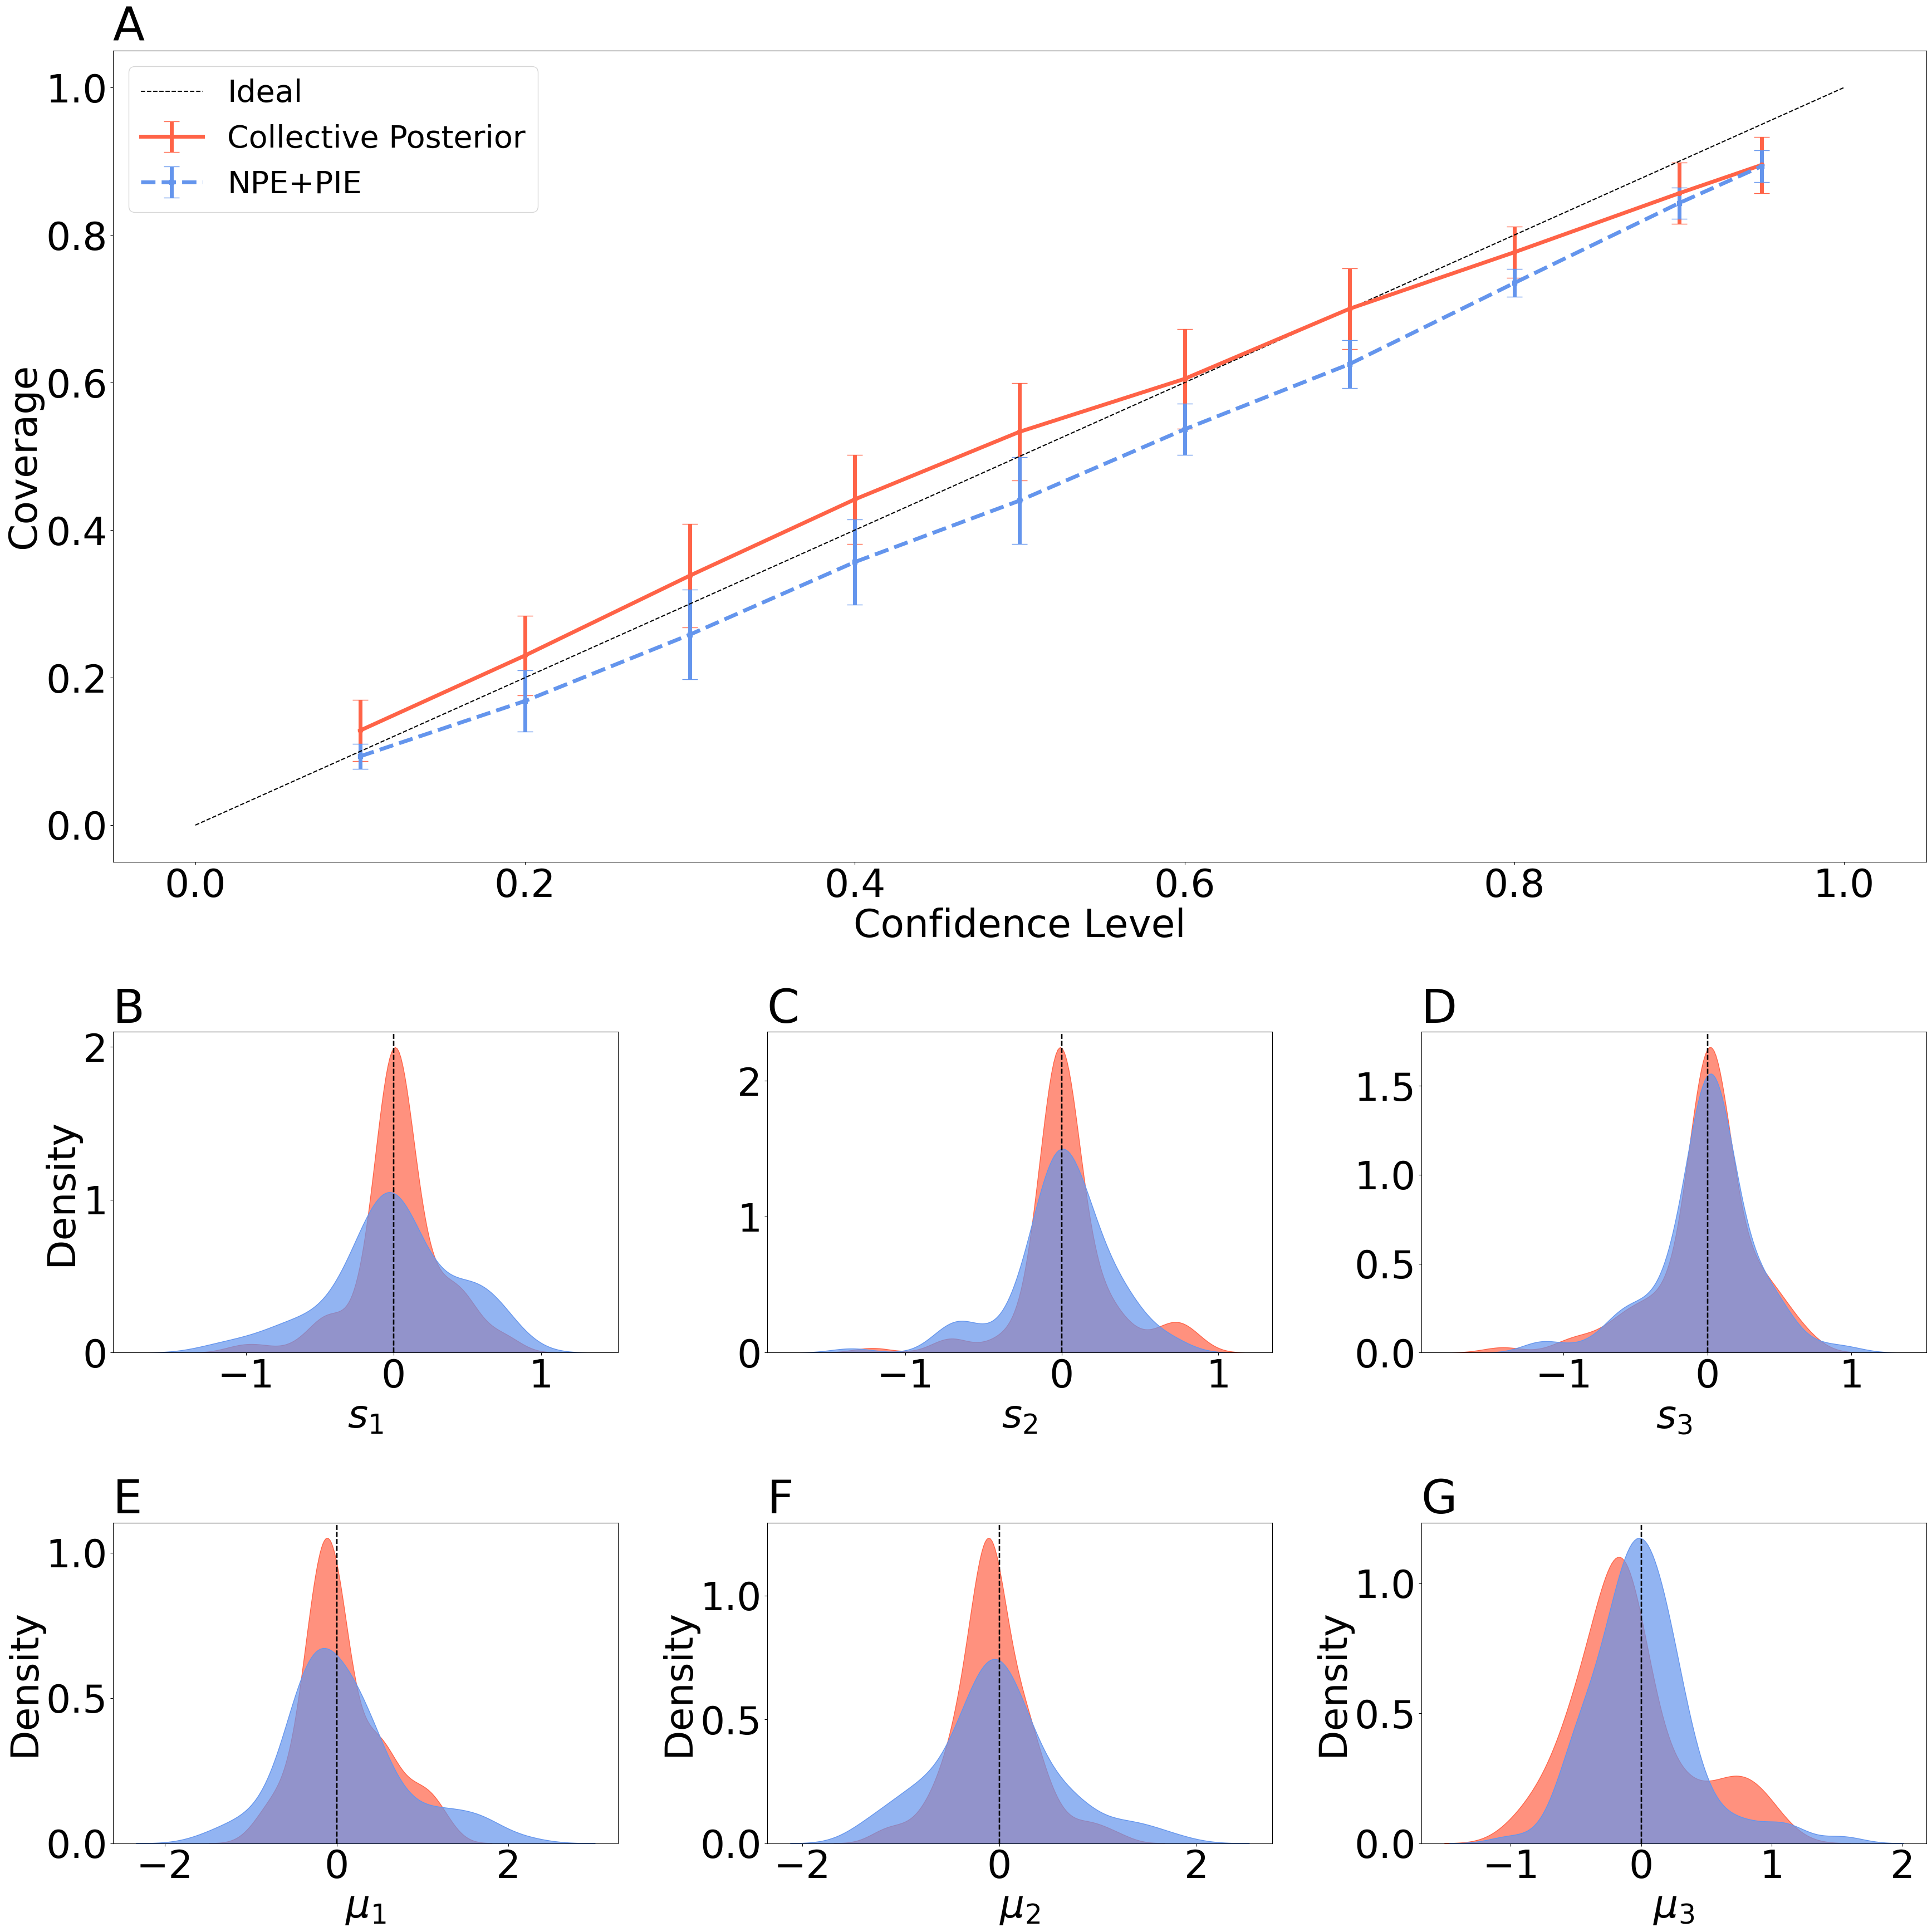

In [22]:
# A - Coverage plots
# B-D - Accuracy plots
mosaic = '''AAA
            AAA
            BCD
            EFG
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(36,36), tight_layout=True)
ax['A'].set_title('A',loc='left')
ax['B'].set_title('B',loc='left')
ax['C'].set_title('C',loc='left')
ax['D'].set_title('D',loc='left')
ax['E'].set_title('E',loc='left')
ax['F'].set_title('F',loc='left')
ax['G'].set_title('G',loc='left')

# Coverage plots in ax B
covs = torch.load(f'covs_EVO_SIM.pt')
covs_iid = torch.load(f'covs_EVO_SIM_iid.pt')
plot_covs(ax=ax['A'], covs1=covs, covs2=covs_iid)
ax['A'].set_xlabel('Confidence Level')
ax['A'].set_ylabel('Coverage')
ax['A'].legend(fontsize=40)
# Accuracy plots in ax C-E
n_params=6


axx = [ax['B'], ax['C'], ax['D'], ax['E'], ax['F'], ax['G']]

cp_acc = torch.load('accus_EVO_SIM.pt')
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='Collective\nPosterior')


iid_acc = torch.load('accus_EVO_SIM_iid.pt')
plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='NPE+PIE')

# ax['A'].legend(loc='upper left')
ax['C'].set_ylabel('')
ax['D'].set_ylabel('')
